

# Miniproyecto 1

En este Jupyter Notebook pueden implementar los códigos necesarios para resolver el **Miniproyecto 1**.

**Importante:** Recuerden que, como grupo, deben **adjuntar el código** en su entrega. En caso de que desarrollen parte del trabajo en este notebook pero **no lo incluyan en la entrega**, **toda la sección de calificación correspondiente al código será evaluada con cero**.

Tengan en cuenta que Coursera utiliza recursos compartidos entre todos los grupos, por lo tanto, si hay muchos equipos trabajando al mismo tiempo, los procesos pueden demorar más de lo previsto.

Pueden agregar todas las celdas de código que consideren necesarias para resolver el miniproyecto. **No hay un límite en este aspecto.**


In [1]:
!pip install kagglehub




[notice] A new release of pip is available: 23.3.2 -> 25.0.1
[notice] To update, run: python -m pip install --upgrade pip


In [2]:
import kagglehub
# Download latest version
path = kagglehub.dataset_download("rm1000/brain-tumor-mri-scans")

print("Path to dataset files:", path)
#print(os.path.abspath(cfg.data_dir))

Path to dataset files: /root/.cache/kagglehub/datasets/rm1000/brain-tumor-mri-scans/versions/1


In [3]:
# Espacio para desarrollar el código del miniproyecto 1

# @title Imports & Safe runtime (ejecutar primero)
# -*- coding: utf-8 -*-
"""Imports y configuración general.

Incluye:
- Librerías base y de visión con PyTorch.
- Limpieza de memoria y sharing strategy (ambientes con /dev/shm limitado).
- Estilo Google en docstrings de clases y funciones a continuación.
"""
import os
import gc
import csv
import math
import time
import json
import random
from pathlib import Path
from dataclasses import dataclass, asdict
from datetime import datetime
from collections import Counter

import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms, models

# Opcional: scikit-learn para splits estratificados y algunas métricas
from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.metrics import (
    confusion_matrix, ConfusionMatrixDisplay,
    classification_report, roc_curve, auc,
    precision_recall_curve, average_precision_score
)

# Pandas para tablas (comparación predicho vs real)
import pandas as pd

# ---- Modo seguro para entornos con memoria compartida limitada ----
try:
    torch.multiprocessing.set_sharing_strategy("file_system")
except Exception:
    pass

if torch.cuda.is_available():
    torch.cuda.empty_cache()
gc.collect()


0

In [4]:

# @title Configuración global (editar aquí los hiperparámetros principales)
# -*- coding: utf-8 -*-
"""Configuración general del experimento.

Atributos:
  data_dir: Ruta a la carpeta raíz con subcarpetas por clase (ImageFolder).
  out_dir: Carpeta de salida para artefactos.
  run_name: Nombre base del experimento (se usará un timestamp para la carpeta).

  device: Dispositivo de cómputo ("cuda" o "cpu").
  num_workers: Num. de workers para DataLoader (0 por modo seguro).
  pin_memory: Si fija páginas de memoria (False por modo seguro).
  batch_size: Tamaño de batch para DataLoader.
  seed: Semilla de reproducibilidad.

  epochs: Épocas máximas de entrenamiento.
  base_lr: Learning rate inicial (se puede ajustar con LR Finder).
  weight_decay: Penalización L2.

  sched_mode: Modo del ReduceLROnPlateau ('min' o 'max').
  sched_factor: Factor de reducción de LR.
  sched_patience: Paciencia (epochs sin mejora) del scheduler.

  lrfind_*: Parámetros del LR Finder (subset, iteraciones, rango).
"""
@dataclass
class Config:
    data_dir: str = "/root/.cache/kagglehub/datasets/rm1000/brain-tumor-mri-scans/versions/1"
    out_dir: str = "./outputs"
    run_name: str = "efficientnetb0_mri_ft"

    # Hardware (modo seguro ON por defecto)
    device: str = "cuda" if torch.cuda.is_available() else "cpu"
    num_workers: int = 0
    pin_memory: bool = False
    batch_size: int = 32
    seed: int = 42

    # Entrenamiento
    epochs: int = 20
    base_lr: float = 1e-5
    weight_decay: float = 1e-4

    # Scheduler: ReduceLROnPlateau
    sched_mode: str = "min"
    sched_factor: float = 0.5
    sched_patience: int = 2

    # LR Finder
    lrfind_subset: int = 500
    lrfind_iters: int = 100
    lrfind_start: float = 1e-6
    lrfind_end: float = 5e-2

cfg = Config()
random.seed(cfg.seed); np.random.seed(cfg.seed); torch.manual_seed(cfg.seed)
os.makedirs(cfg.out_dir, exist_ok=True)


In [5]:

# @title Transformaciones baseline
# -*- coding: utf-8 -*-
"""Transformaciones consistentes con ImageNet (para pesos preentrenados).

Se convierte a RGB (3 canales), se redimensiona a 224x224 y se normaliza con
las medias y desviaciones estándar de ImageNet.
"""
IMG_SIZE = (224, 224)
MEAN = [0.485, 0.456, 0.406]
STD  = [0.229, 0.224, 0.225]

to_rgb = transforms.Lambda(lambda x: x.convert("RGB"))

train_tfms = transforms.Compose([
    transforms.Resize(IMG_SIZE),
    to_rgb,
    transforms.ToTensor(),
    transforms.Normalize(MEAN, STD),
])

test_tfms = train_tfms


In [6]:

# @title DataModule
# -*- coding: utf-8 -*-
class DataModule:
    """Encapsula carga, splits y DataLoaders.

    Usa `ImageFolder` y realiza una división **estratificada** 80/10/10 sin mover archivos
    (se trabaja con índices).

    Atributos:
      cfg: Configuración global.
      idx_to_class: Mapeo de índice -> nombre de clase.
      _train, _val, _test: Subsets para cada split.

    Métodos:
      setup: Prepara datasets y splits.
      loaders: Retorna DataLoaders para train/val/test.

    """
    def __init__(self, cfg: Config):
        self.cfg = cfg
        self.idx_to_class = {}
        self._train = self._val = self._test = None

    def setup(self) -> None:
        """Carga el dataset y crea splits estratificados 80/10/10."""
        base_ds = datasets.ImageFolder(self.cfg.data_dir, transform=train_tfms)
        self.idx_to_class = {i: c for c, i in base_ds.class_to_idx.items()}
        targets = np.array([y for _, y in base_ds.samples])

        sss = StratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=self.cfg.seed)
        train_idx, temp_idx = next(sss.split(np.zeros(len(targets)), targets))

        y_temp = targets[temp_idx]
        sss2 = StratifiedShuffleSplit(n_splits=1, test_size=0.5, random_state=self.cfg.seed)
        val_rel, test_rel = next(sss2.split(np.zeros(len(y_temp)), y_temp))
        val_idx = temp_idx[val_rel]
        test_idx = temp_idx[test_rel]

        self._train = Subset(datasets.ImageFolder(self.cfg.data_dir, transform=train_tfms), train_idx)
        self._val   = Subset(datasets.ImageFolder(self.cfg.data_dir, transform=test_tfms),  val_idx)
        self._test  = Subset(datasets.ImageFolder(self.cfg.data_dir, transform=test_tfms),  test_idx)

    def loaders(self):
        """Construye DataLoaders para train/val/test.

        Returns:
          Tuple[DataLoader, DataLoader, DataLoader]: loaders de train, val y test.
        """
        mk = lambda ds, sh: DataLoader(
            ds, batch_size=self.cfg.batch_size, shuffle=sh,
            num_workers=self.cfg.num_workers, pin_memory=self.cfg.pin_memory
        )
        return mk(self._train, True), mk(self._val, False), mk(self._test, False)


Sizes -> train: 5618 | val: 702 | test: 703
Class mapping: {0: 'glioma', 1: 'healthy', 2: 'meningioma', 3: 'pituitary'}
Train dist.: {'glioma': 1297, 'healthy': 1600, 'meningioma': 1316, 'pituitary': 1405}
Val dist.  : {'glioma': 162, 'healthy': 200, 'meningioma': 164, 'pituitary': 176}
Test dist. : {'glioma': 162, 'healthy': 200, 'meningioma': 165, 'pituitary': 176}


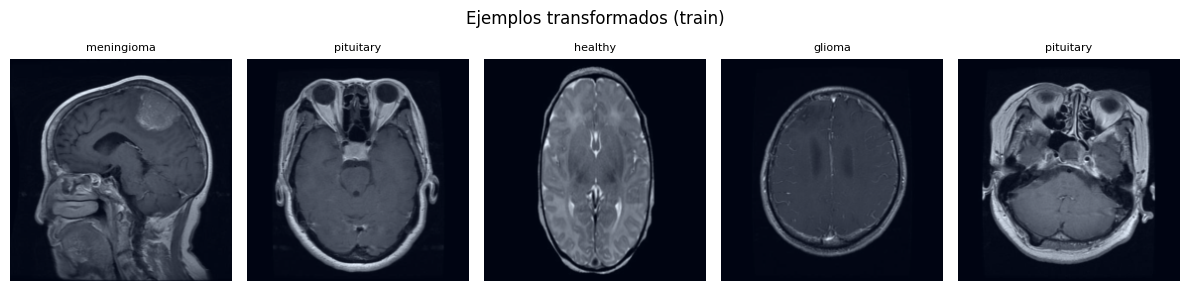

In [7]:

# @title Chequeos de split + muestras visuales del train
# -*- coding: utf-8 -*-
def _split_counts(subset: Subset) -> dict:
    base_targets = np.array(subset.dataset.targets)
    idxs = np.array(subset.indices)
    cnt = Counter(base_targets[idxs])
    return {int(k): int(v) for k, v in cnt.items()}

dm = DataModule(cfg)
dm.setup()
train_loader, val_loader, test_loader = dm.loaders()

print(f"Sizes -> train: {len(train_loader.dataset)} | val: {len(val_loader.dataset)} | test: {len(test_loader.dataset)}")
print("Class mapping:", dm.idx_to_class)
print("Train dist.:", {dm.idx_to_class[k]: v for k, v in sorted(_split_counts(train_loader.dataset).items())})
print("Val dist.  :", {dm.idx_to_class[k]: v for k, v in sorted(_split_counts(val_loader.dataset).items())})
print("Test dist. :", {dm.idx_to_class[k]: v for k, v in sorted(_split_counts(test_loader.dataset).items())})

# Visualizar 5 imágenes transformadas del train
fig, axes = plt.subplots(1, 5, figsize=(12, 3))
sample_ids = random.sample(range(len(train_loader.dataset)), min(5, len(train_loader.dataset)))
for ax, idx in zip(axes, sample_ids):
    img, y = train_loader.dataset[idx]
    # Normalizar a [0,1] para visualización
    arr = img.permute(1, 2, 0).numpy()
    arr = (arr - arr.min()) / (arr.max() - arr.min() + 1e-8)
    ax.imshow(arr)
    ax.set_title(dm.idx_to_class[y], fontsize=8)
    ax.axis("off")
plt.suptitle("Ejemplos transformados (train)")
plt.tight_layout()
plt.show()


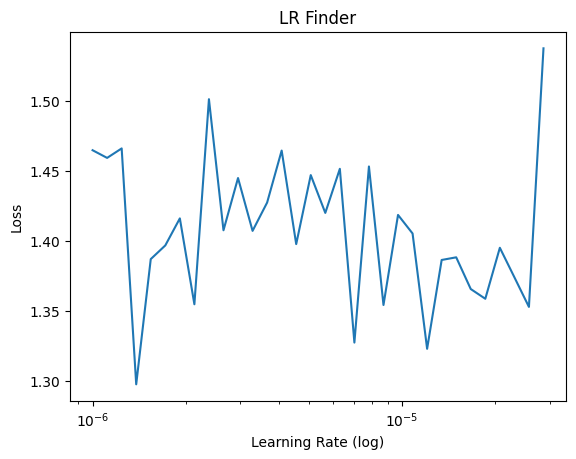

Sugerencia de LR inicial ≈ 8.71e-06  -> Asigna manualmente a cfg.base_lr si deseas.


In [8]:

# @title LR Finder
# -*- coding: utf-8 -*-
def lr_range_test(model: nn.Module, dataloader: DataLoader,
                  start_lr: float, end_lr: float, num_iters: int):
    """Ejecuta un LR range test (Smith, 2015/2017).

    Args:
      model: Red a evaluar (con cabeza final correcta).
      dataloader: Loader de un subset de entrenamiento.
      start_lr: LR inicial del barrido.
      end_lr: LR final del barrido (escala log).
      num_iters: Número de iteraciones a muestrear.

    Returns:
      Tuple[np.ndarray, np.ndarray]: (lrs, losses)
    """
    lrs, losses = [], []
    optimizer = torch.optim.Adam(model.parameters(), lr=start_lr)
    criterion = nn.CrossEntropyLoss()
    lr_lambda = lambda it: (end_lr/start_lr) ** (it / max(1, num_iters))

    model.train()
    it = 0
    for images, targets in dataloader:
        if it >= num_iters:
            break
        # Actualizar LR progresivamente
        lr = start_lr * ((end_lr/start_lr) ** (it / max(1, num_iters)))
        for g in optimizer.param_groups:
            g['lr'] = lr

        images, targets = images.to(cfg.device), targets.to(cfg.device)
        optimizer.zero_grad(set_to_none=True)
        logits = model(images)
        loss = criterion(logits, targets)
        loss.backward()
        optimizer.step()

        lrs.append(lr); losses.append(loss.item()); it += 1

    return np.array(lrs), np.array(losses)

def _build_model_for_lrfind(num_classes: int) -> nn.Module:
    """Construye EfficientNet-B0 con cabeza final de num_classes para LR Finder."""
    m = models.efficientnet_b0(weights=models.EfficientNet_B0_Weights.IMAGENET1K_V1)
    in_f = m.classifier[1].in_features
    m.classifier[1] = nn.Linear(in_f, num_classes)
    return m.to(cfg.device)

subset_size = min(cfg.lrfind_subset, len(train_loader.dataset))
subset_idx = random.sample(range(len(train_loader.dataset)), subset_size)
subset_loader = DataLoader(
    Subset(train_loader.dataset, subset_idx),
    batch_size=min(cfg.batch_size, 16),
    shuffle=True, num_workers=0, pin_memory=False
)

model_tmp = _build_model_for_lrfind(num_classes=len(dm.idx_to_class))
lrs, losses = lr_range_test(model_tmp, subset_loader,
                            cfg.lrfind_start, cfg.lrfind_end, cfg.lrfind_iters)

plt.figure()
plt.plot(lrs, losses)
plt.xscale("log")
plt.xlabel("Learning Rate (log)")
plt.ylabel("Loss")
plt.title("LR Finder")
plt.show()

# Sugerencia automática simple (mínimo suavizado)
loss_s = np.convolve(losses, np.ones(5)/5, mode='valid')
best_i = int(np.argmin(loss_s)) if loss_s.size > 0 else 0
suggested_lr = float(lrs[max(0, best_i-3)]) if lrs.size > 0 else cfg.base_lr
print(f"Sugerencia de LR inicial ≈ {suggested_lr:.2e}  -> Asigna manualmente a cfg.base_lr si deseas.")


In [9]:

# @title ModelBuilder
# -*- coding: utf-8 -*-
class ModelBuilder:
    """Crea el modelo EfficientNet-B0 con cabeza para 4 clases.

    Args:
      cfg: Configuración global.
      num_classes: Número de clases (4 en este microproyecto).

    Returns:
      nn.Module: Modelo listo para entrenamiento en cfg.device.
    """
    def __init__(self, cfg: Config, num_classes: int):
        self.cfg = cfg
        self.num_classes = num_classes

    def build(self) -> nn.Module:
        """Instancia EfficientNet-B0 preentrenada (ImageNet) y sustituye el clasificador final."""
        m = models.efficientnet_b0(weights=models.EfficientNet_B0_Weights.IMAGENET1K_V1)
        in_features = m.classifier[1].in_features
        m.classifier[1] = nn.Linear(in_features, self.num_classes)
        return m.to(self.cfg.device)


In [10]:

# @title Trainer
# -*- coding: utf-8 -*-
def criterion_fn() -> nn.Module:
    """Devuelve la función de pérdida para clasificación."""
    return nn.CrossEntropyLoss()

class EarlyStopper:
    """Detiene el entrenamiento si no hay mejora en validación.

    Args:
      patience: Número de epochs sin mejora permitidos.
      mode: 'min' para pérdida, 'max' para métrica.

    Métodos:
      step(value): Retorna True si se agotó la paciencia; False en caso contrario.
    """
    def __init__(self, patience: int = 5, mode: str = "min"):
        self.patience = patience
        self.mode = mode
        self.best = None
        self.bad = 0

    def step(self, value: float) -> bool:
        if self.best is None:
            self.best = value
            self.bad = 0
            return False

        improved = (value < self.best) if self.mode == "min" else (value > self.best)
        if improved:
            self.best = value
            self.bad = 0
            return False

        self.bad += 1
        return self.bad >= self.patience

class Trainer:
    """Entrenador con logging básico y scheduler ReduceLROnPlateau."""
    def __init__(self, cfg: Config):
        self.cfg = cfg

    def _epoch(self, model: nn.Module, loader: DataLoader,
               criterion: nn.Module, optimizer: torch.optim.Optimizer = None):
        """Ejecuta una época de entrenamiento o validación.

        Args:
          model: Red a entrenar/evaluar.
          loader: DataLoader del split correspondiente.
          criterion: Función de pérdida.
          optimizer: Optimizador (si None, modo validación).

        Returns:
          Tuple[float, float, float]: (loss_prom, acc, macro_f1)
        """
        train_mode = optimizer is not None
        model.train() if train_mode else model.eval()

        total = 0
        loss_sum = 0.0
        correct = 0
        # Cálculo de macro-F1 manual (para evitar dependencias)
        f1_counts = {c: {'tp': 0, 'fp': 0, 'fn': 0} for c in range(4)}

        with torch.set_grad_enabled(train_mode):
            for images, targets in loader:
                images, targets = images.to(self.cfg.device), targets.to(self.cfg.device)
                if train_mode:
                    optimizer.zero_grad(set_to_none=True)
                logits = model(images)
                loss = criterion(logits, targets)
                if train_mode:
                    loss.backward()
                    optimizer.step()

                loss_sum += loss.item() * images.size(0)
                total += images.size(0)

                preds = logits.argmax(1)
                correct += (preds == targets).sum().item()

                for c in range(4):
                    tp = ((preds == c) & (targets == c)).sum().item()
                    fp = ((preds == c) & (targets != c)).sum().item()
                    fn = ((preds != c) & (targets == c)).sum().item()
                    f1_counts[c]['tp'] += tp
                    f1_counts[c]['fp'] += fp
                    f1_counts[c]['fn'] += fn

        loss_avg = loss_sum / max(1, total)
        acc = correct / max(1, total)

        f1s = []
        for c in f1_counts:
            tp, fp, fn = f1_counts[c]['tp'], f1_counts[c]['fp'], f1_counts[c]['fn']
            prec = tp / (tp + fp + 1e-12) if (tp + fp) > 0 else 0.0
            rec  = tp / (tp + fn + 1e-12) if (tp + fn) > 0 else 0.0
            f1 = 0.0 if (prec + rec) == 0 else 2 * prec * rec / (prec + rec)
            f1s.append(f1)
        macro_f1 = float(np.mean(f1s))

        return loss_avg, acc, macro_f1

    def fit(self, model: nn.Module, train_loader: DataLoader, val_loader: DataLoader):
        """Entrena el modelo con early stopping y ReduceLROnPlateau."""
        optimizer = torch.optim.Adam(model.parameters(), lr=cfg.base_lr, weight_decay=cfg.weight_decay)
        scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
            optimizer, mode=cfg.sched_mode, factor=cfg.sched_factor,
            patience=cfg.sched_patience
        )
        early = EarlyStopper(patience=5, mode="min")
        history = {"train_loss": [], "val_loss": [], "val_acc": [], "val_f1": []}
        best_w = None
        best_val = float("inf")

        for ep in range(1, cfg.epochs + 1):
            tr_loss, _, _ = self._epoch(model, train_loader, criterion_fn(), optimizer)
            val_loss, val_acc, val_f1 = self._epoch(model, val_loader, criterion_fn(), optimizer=None)
            
            # Get current LR before scheduler.step
            current_lr = optimizer.param_groups[0]['lr']
            scheduler.step(val_loss)
            new_lr = optimizer.param_groups[0]['lr']
            
            history["train_loss"].append(tr_loss)
            history["val_loss"].append(val_loss)
            history["val_acc"].append(val_acc)
            history["val_f1"].append(val_f1)

            print(f"Epoch {ep:03d}/{cfg.epochs} | "
                  f"train_loss={tr_loss:.4f} | val_loss={val_loss:.4f} | "
                  f"val_acc={val_acc:.4f} | val_f1={val_f1:.4f} | lr={current_lr:.2e}")
            
            if new_lr < current_lr:
                print(f"  ReduceLROnPlateau: reducing lr to {new_lr:.2e}")

            if val_loss < best_val:
                best_val = val_loss
                best_w = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}

            if early.step(val_loss):
                print("Early stopping activado.")
                break

        if best_w is not None:
            model.load_state_dict(best_w)

        # Guardar mejor checkpoint e historia
        torch.save(model.state_dict(), os.path.join(cfg.out_dir, f"{cfg.run_name}_best.pth"))
        np.save(os.path.join(cfg.out_dir, f"{cfg.run_name}_history.npy"), history, allow_pickle=True)
        return model, history

    def validate(self, model: nn.Module, loader: DataLoader):
        """Evalúa un modelo en un DataLoader y retorna métricas básicas."""
        return self._epoch(model, loader, criterion_fn(), optimizer=None)


In [11]:

# @title ExperimentLogger
# -*- coding: utf-8 -*-
class ExperimentLogger:
    """Logger minimalista sobre disco para consolidar un experimento.

    Crea una carpeta única por corrida: `outputs/<run_name>_<timestamp>/`
    y mantiene un alias `<run_name>_latest` (symlink si el SO lo permite).

    Guarda:
      - config.json, classes.json, split_sizes.json, split_indices.json
      - history.npy, history.csv, curves.png, val_metrics.png
      - test_metrics.json, test_confusion_matrix.png
      - requirements.freeze.txt (snapshot aproximado del entorno)
      - (Opcional) lr_finder.png
    """
    def __init__(self, cfg: Config, idx_to_class: dict = None, run_dir: str = None):
        ts = datetime.now().strftime("%Y%m%d_%H%M%S")
        base = Path(cfg.out_dir)
        base.mkdir(parents=True, exist_ok=True)
        self.run_dir = Path(run_dir) if run_dir else base / f"{cfg.run_name}_{ts}"
        self.run_dir.mkdir(parents=True, exist_ok=True)
        self.cfg = cfg
        self.idx_to_class = idx_to_class or {}

        latest = base / f"{cfg.run_name}_latest"
        if latest.exists() and latest.is_symlink():
            latest.unlink()
        try:
            latest.symlink_to(self.run_dir, target_is_directory=True)
        except Exception:
            # En Windows puede fallar: ignorar
            pass

    # ---- Config & Data ----
    def save_config(self) -> None:
        with open(self.run_dir / "config.json", "w") as f:
            json.dump(asdict(self.cfg), f, indent=2, default=str)

    def save_class_map(self, class_to_idx: dict = None, idx_to_class: dict = None) -> None:
        if class_to_idx is None and idx_to_class is None:
            idx_to_class = self.idx_to_class
            class_to_idx = {v: k for k, v in idx_to_class.items()}
        if idx_to_class is None:
            idx_to_class = {v: k for k, v in class_to_idx.items()}
        with open(self.run_dir / "classes.json", "w") as f:
            json.dump({"class_to_idx": class_to_idx, "idx_to_class": idx_to_class}, f, indent=2)

    def save_split_indices(self, train_subset: Subset, val_subset: Subset, test_subset: Subset) -> None:
        def get_idx(subset):
            return list(map(int, getattr(subset, "indices", [])))
        payload = {
            "train_indices": get_idx(train_subset),
            "val_indices": get_idx(val_subset),
            "test_indices": get_idx(test_subset),
        }
        with open(self.run_dir / "split_indices.json", "w") as f:
            json.dump(payload, f, indent=2)

    def save_split_sizes(self, train_loader: DataLoader, val_loader: DataLoader, test_loader: DataLoader) -> None:
        sizes = {
            "train": len(train_loader.dataset),
            "val": len(val_loader.dataset),
            "test": len(test_loader.dataset),
            "total": sum([len(train_loader.dataset), len(val_loader.dataset), len(test_loader.dataset)]),
        }
        with open(self.run_dir / "split_sizes.json", "w") as f:
            json.dump(sizes, f, indent=2)

    # ---- History ----
    def save_history(self, history: dict) -> None:
        np.save(self.run_dir / "history.npy", history, allow_pickle=True)
        # CSV
        keys = list(history.keys())
        with open(self.run_dir / "history.csv", "w", newline="") as f:
            wr = csv.writer(f)
            wr.writerow(["epoch"] + keys)
            for i in range(len(history[keys[0]])):
                row = [i + 1] + [history[k][i] for k in keys]
                wr.writerow(row)

    def plot_curves(self, history: dict, filename: str = "curves.png") -> None:
        plt.figure()
        if "train_loss" in history:
            plt.plot(history["train_loss"], label="train_loss")
        if "val_loss" in history:
            plt.plot(history["val_loss"], label="val_loss")
        plt.title("Loss curves"); plt.legend(); plt.xlabel("epoch"); plt.ylabel("loss")
        plt.savefig(self.run_dir / filename, bbox_inches="tight", dpi=150)
        plt.close()

        if "val_acc" in history or "val_f1" in history:
            plt.figure()
            if "val_acc" in history:
                plt.plot(history["val_acc"], label="val_acc")
            if "val_f1" in history:
                plt.plot(history["val_f1"], label="val_macro_f1")
            plt.title("Validation metrics"); plt.legend(); plt.xlabel("epoch")
            plt.savefig(self.run_dir / "val_metrics.png", bbox_inches="tight", dpi=150)
            plt.close()

    # ---- Test eval ----
    @torch.no_grad()
    def evaluate_and_save(self, model: nn.Module, loader: DataLoader, criterion: nn.Module,
                          idx_to_class: dict = None, file_prefix: str = "test") -> dict:
        device = next(model.parameters()).device
        model.eval()
        all_logits, all_targets = [], []
        running_loss = 0.0
        n = 0

        for images, targets in loader:
            images, targets = images.to(device), targets.to(device)
            logits = model(images)
            loss = criterion(logits, targets)
            running_loss += loss.item() * images.size(0)
            n += images.size(0)
            all_logits.append(logits.cpu())
            all_targets.append(targets.cpu())

        loss_avg = running_loss / max(1, n)
        logits = torch.cat(all_logits, dim=0)
        targets = torch.cat(all_targets, dim=0)
        preds = logits.argmax(dim=1)
        acc = (preds == targets).float().mean().item()

        # macro-F1 manual
        num_classes = int(logits.shape[1])
        f1s = []
        for c in range(num_classes):
            tp = ((preds == c) & (targets == c)).sum().item()
            fp = ((preds == c) & (targets != c)).sum().item()
            fn = ((preds != c) & (targets == c)).sum().item()
            prec = tp / (tp + fp + 1e-12) if (tp + fp) > 0 else 0.0
            rec  = tp / (tp + fn + 1e-12) if (tp + fn) > 0 else 0.0
            f1 = 0.0 if (prec + rec) == 0 else (2 * prec * rec) / (prec + rec)
            f1s.append(f1)
        macro_f1 = float(np.mean(f1s))

        metrics = {"loss": float(loss_avg), "acc": float(acc), "macro_f1": float(macro_f1)}
        with open(self.run_dir / f"{file_prefix}_metrics.json", "w") as f:
            json.dump(metrics, f, indent=2)

        cm = confusion_matrix(targets.numpy(), preds.numpy(), labels=list(range(num_classes)))
        labels = [ (idx_to_class or self.idx_to_class).get(i, str(i)) for i in range(num_classes) ]
        disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
        fig, ax = plt.subplots(figsize=(5, 5))
        disp.plot(ax=ax, colorbar=False, cmap="Blues", xticks_rotation=45)
        plt.title(f"Confusion Matrix – {file_prefix.upper()}")
        plt.tight_layout()
        fig.savefig(self.run_dir / f"{file_prefix}_confusion_matrix.png", dpi=150)
        plt.close(fig)
        return metrics

    # ---- Checkpoint & Env ----
    def note_checkpoint(self, ckpt_path: str) -> None:
        with open(self.run_dir / "checkpoint.txt", "w") as f:
            f.write(str(Path(ckpt_path).resolve()))

    def freeze_requirements(self) -> None:
        try:
            import pkg_resources
            with open(self.run_dir / "requirements.freeze.txt", "w") as f:
                for dist in sorted(pkg_resources.working_set, key=lambda d: d.project_name.lower()):
                    f.write(f"{dist.project_name}=={dist.version}\n")
        except Exception as e:
            with open(self.run_dir / "requirements.freeze.txt", "w") as f:
                f.write(f"# pkg_resources unavailable: {e}\n")

    # ---- LR Finder figure ----
    def save_lr_finder(self, lrs: np.ndarray, losses: np.ndarray, filename: str = "lr_finder.png") -> None:
        if lrs is None or losses is None or len(lrs) == 0:
            return
        plt.figure()
        plt.plot(lrs, losses)
        plt.xscale("log")
        plt.xlabel("Learning Rate (log)")
        plt.ylabel("Loss")
        plt.title("LR Range Test")
        plt.savefig(self.run_dir / filename, bbox_inches="tight", dpi=150)
        plt.close()


In [12]:

# @title main(cfg)
# -*- coding: utf-8 -*-
def main(cfg: Config):
    """Ejecuta el ciclo de entrenamiento y registro del experimento.

    Flujo:
      1) Prepara DataModule (train/val/test) y modelo.
      2) Entrena con Trainer (ReduceLROnPlateau + EarlyStopping).
      3) Evalúa en test.
      4) Registra artefactos con ExperimentLogger.
    """
    # Datos
    dm = DataModule(cfg)
    dm.setup()
    train_loader, val_loader, test_loader = dm.loaders()

    # Modelo
    builder = ModelBuilder(cfg, num_classes=len(dm.idx_to_class))
    model = builder.build()

    # Entrenamiento
    trainer = Trainer(cfg)
    model, history = trainer.fit(model, train_loader, val_loader)

    # Evaluación en test
    test_loss, test_acc, test_f1 = trainer.validate(model, test_loader)
    print(f"TEST | loss={test_loss:.4f} | acc={test_acc:.4f} | macro_f1={test_f1:.4f}")

    # Logging consolidado
    logger = ExperimentLogger(cfg, idx_to_class=dm.idx_to_class)
    logger.save_config()
    logger.save_class_map()
    logger.save_split_sizes(train_loader, val_loader, test_loader)
    logger.save_split_indices(train_loader.dataset, val_loader.dataset, test_loader.dataset)
    logger.freeze_requirements()
    logger.save_history(history)
    logger.plot_curves(history)
    logger.note_checkpoint(os.path.join(cfg.out_dir, f"{cfg.run_name}_best.pth"))
    _ = logger.evaluate_and_save(model, test_loader, criterion_fn(),
                                 idx_to_class=dm.idx_to_class, file_prefix="test")


main(cfg)

print(f"Dispositivo configurado: {cfg.device}")
print(f"Dataset: {cfg.data_dir}")
print(f"Batch size: {cfg.batch_size}")
print(f"Épocas: {cfg.epochs}")


Epoch 001/20 | train_loss=1.1311 | val_loss=0.7787 | val_acc=0.8775 | val_f1=0.8703 | lr=1.00e-05
Epoch 002/20 | train_loss=0.6674 | val_loss=0.4480 | val_acc=0.8946 | val_f1=0.8902 | lr=1.00e-05
Epoch 003/20 | train_loss=0.4328 | val_loss=0.2990 | val_acc=0.9003 | val_f1=0.8969 | lr=1.00e-05
Epoch 004/20 | train_loss=0.3346 | val_loss=0.2356 | val_acc=0.9202 | val_f1=0.9184 | lr=1.00e-05
Epoch 005/20 | train_loss=0.2699 | val_loss=0.1956 | val_acc=0.9316 | val_f1=0.9304 | lr=1.00e-05
Epoch 006/20 | train_loss=0.2251 | val_loss=0.1548 | val_acc=0.9558 | val_f1=0.9548 | lr=1.00e-05
Epoch 007/20 | train_loss=0.1869 | val_loss=0.1351 | val_acc=0.9573 | val_f1=0.9561 | lr=1.00e-05
Epoch 008/20 | train_loss=0.1560 | val_loss=0.1102 | val_acc=0.9644 | val_f1=0.9634 | lr=1.00e-05
Epoch 009/20 | train_loss=0.1367 | val_loss=0.0931 | val_acc=0.9729 | val_f1=0.9723 | lr=1.00e-05
Epoch 010/20 | train_loss=0.1247 | val_loss=0.0798 | val_acc=0.9729 | val_f1=0.9724 | lr=1.00e-05
Epoch 011/20 | train

In [13]:

# @title Consolidar artefactos de una corrida ya existente
# -*- coding: utf-8 -*-
dm = DataModule(cfg)
dm.setup()
train_loader, val_loader, test_loader = dm.loaders()

logger = ExperimentLogger(cfg, idx_to_class=dm.idx_to_class)
logger.save_config()
logger.save_class_map()
logger.save_split_sizes(train_loader, val_loader, test_loader)
logger.save_split_indices(train_loader.dataset, val_loader.dataset, test_loader.dataset)
logger.freeze_requirements()

# Historia previa
hist_path = os.path.join(cfg.out_dir, f"{cfg.run_name}_history.npy")
if os.path.exists(hist_path):
    history = np.load(hist_path, allow_pickle=True).item()
    logger.save_history(history)
    logger.plot_curves(history)

# Cargar mejor checkpoint y evaluar test
builder = ModelBuilder(cfg, num_classes=len(dm.idx_to_class))
model = builder.build().to(cfg.device)
best_ckpt = os.path.join(cfg.out_dir, f"{cfg.run_name}_best.pth")
if os.path.exists(best_ckpt):
    state = torch.load(best_ckpt, map_location=cfg.device)
    model.load_state_dict(state)
    logger.note_checkpoint(best_ckpt)
    _ = logger.evaluate_and_save(model, test_loader, criterion_fn(),
                                 idx_to_class=dm.idx_to_class, file_prefix="test")
else:
    print(" No se encontró el checkpoint para consolidación:", best_ckpt)


In [14]:

# @title Generar y guardar y_true, y_pred, y_proba
# -*- coding: utf-8 -*-
analysis_dir = os.path.join(cfg.out_dir, "analysis")
os.makedirs(analysis_dir, exist_ok=True)

builder = ModelBuilder(cfg, num_classes=len(dm.idx_to_class))
model = builder.build().to(cfg.device)
best_path = os.path.join(cfg.out_dir, f"{cfg.run_name}_best.pth")
assert os.path.exists(best_path), f"No existe el checkpoint: {best_path}"
model.load_state_dict(torch.load(best_path, map_location=cfg.device))
model.eval()

y_true, y_pred, y_proba = [], [], []

with torch.no_grad():
    for i in range(len(test_loader.dataset)):
        img, y = test_loader.dataset[i]
        logits = model(img.unsqueeze(0).to(cfg.device))
        probs = F.softmax(logits, dim=1).cpu().numpy()[0]
        y_true.append(int(y))
        y_pred.append(int(np.argmax(probs)))
        y_proba.append(probs.astype(np.float32))

y_true = np.array(y_true)
y_pred = np.array(y_pred)
y_proba = np.vstack(y_proba)

np.save(os.path.join(analysis_dir, "y_true.npy"), y_true)
np.save(os.path.join(analysis_dir, "y_pred.npy"), y_pred)
np.save(os.path.join(analysis_dir, "y_proba.npy"), y_proba)

print("Listo: y_true, y_pred, y_proba guardados en ./outputs/analysis")
print(classification_report(y_true, y_pred, target_names=[dm.idx_to_class[i] for i in range(len(dm.idx_to_class))], digits=4))


Listo: y_true, y_pred, y_proba guardados en ./outputs/analysis
              precision    recall  f1-score   support

      glioma     1.0000    0.9938    0.9969       162
     healthy     1.0000    1.0000    1.0000       200
  meningioma     0.9880    0.9939    0.9909       165
   pituitary     0.9943    0.9943    0.9943       176

    accuracy                         0.9957       703
   macro avg     0.9956    0.9955    0.9955       703
weighted avg     0.9957    0.9957    0.9957       703



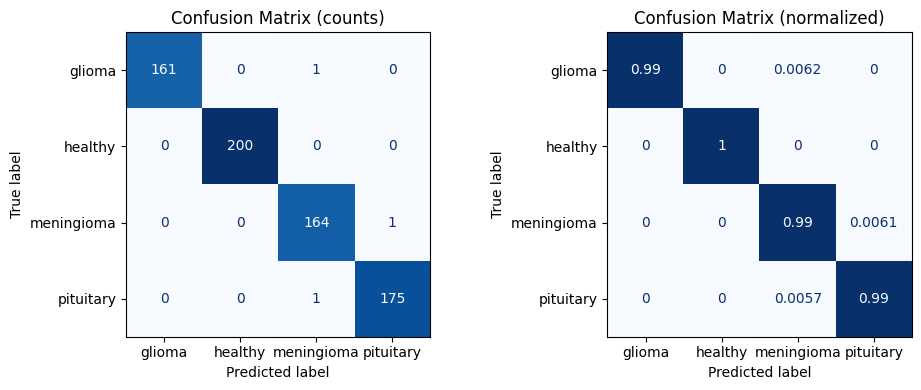

 Guardado: ./outputs/analysis/confusion_matrices.png


In [15]:

# @title Confusion matrices
# -*- coding: utf-8 -*-
y_true = np.load(os.path.join(analysis_dir, "y_true.npy"))
y_pred = np.load(os.path.join(analysis_dir, "y_pred.npy"))
class_names = [dm.idx_to_class[i] for i in range(len(dm.idx_to_class))]

cm = confusion_matrix(y_true, y_pred, labels=list(range(len(class_names))))
cm_norm = confusion_matrix(y_true, y_pred, labels=list(range(len(class_names))), normalize='true')

fig, ax = plt.subplots(1, 2, figsize=(10, 4))
ConfusionMatrixDisplay(cm, display_labels=class_names).plot(ax=ax[0], colorbar=False, cmap="Blues")
ax[0].set_title("Confusion Matrix (counts)")
ConfusionMatrixDisplay(cm_norm, display_labels=class_names).plot(ax=ax[1], colorbar=False, cmap="Blues")
ax[1].set_title("Confusion Matrix (normalized)")
plt.tight_layout()
cm_path = os.path.join(analysis_dir, "confusion_matrices.png")
plt.savefig(cm_path, dpi=150, bbox_inches="tight")
plt.show()
print(" Guardado:", cm_path)
